## Analysing PPG signals from smart rings

This notebook presents a workflow of how to process PPG data from green LED to extract heart rate

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import heartpy as hp

sample_rate = 20

In [7]:
#load the example file
data = hp.get_data('m_green.csv')

First let's take a look at the unproccessed signal

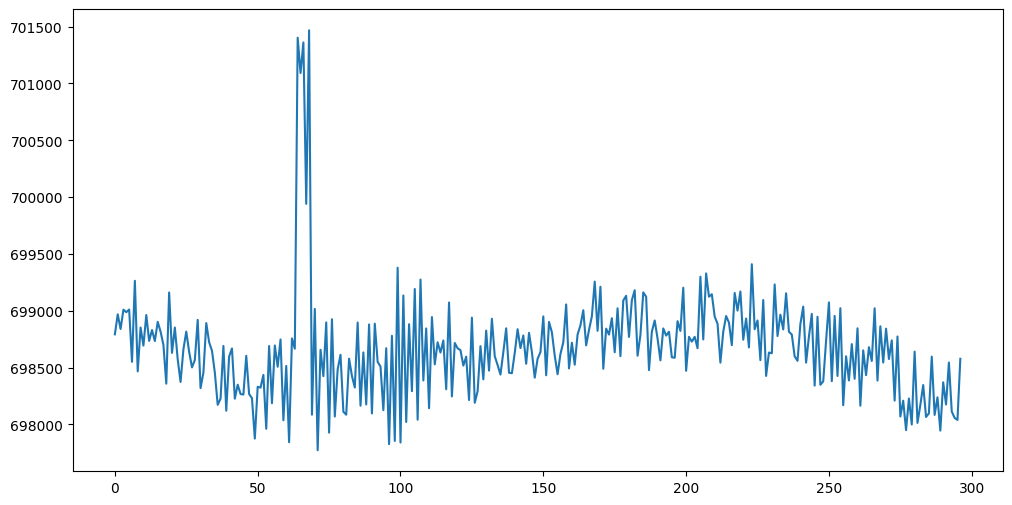

In [15]:
plt.figure(figsize=(12,6))
plt.plot(data)
plt.show()

#### Signal is noisy, but it it there

Analysing is relatively straightforward. We need to do a few standard signal processing tricks:

- filter the signal
- run the analysis
- visualise the analysis

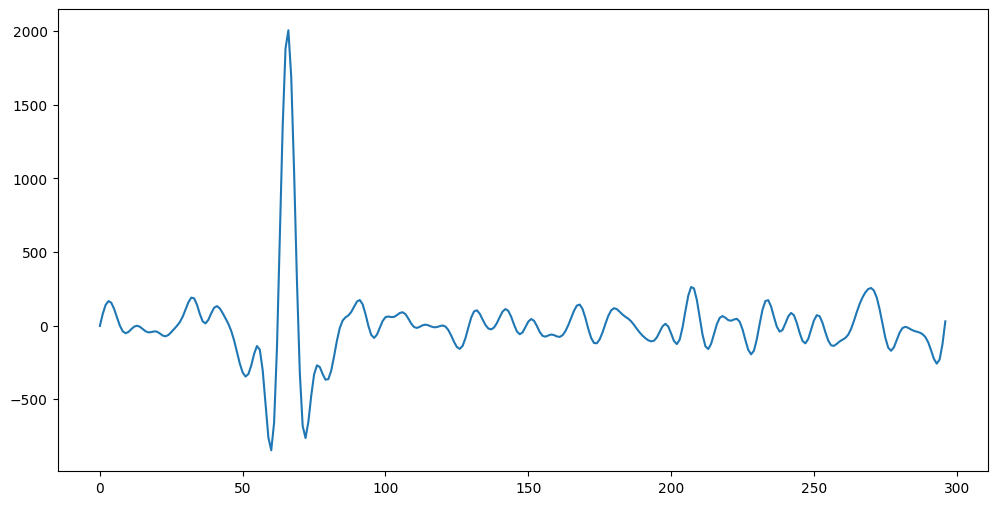

In [27]:
filtered_ppg = hp.filter_signal(data, 
                                cutoff = [0.5, 2.5], 
                                filtertype = 'bandpass',
                                sample_rate = sample_rate, 
                                order = 3,
                                return_top = False)

#And let's plot the same segment as under 'zoomed in!' above
plt.figure(figsize=(12,6))
plt.plot(filtered_ppg)
plt.show()

#### Now we need to detect the peaks

In heartpy it is done through process() function

In [28]:

wd, m = hp.process(filtered_ppg, sample_rate=sample_rate, high_precision = True)

c:\Users\kiril\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\numpy\ma\core.py:5403: RuntimeWarning: Mean of empty slice
  result = super().mean(axis=axis, dtype=dtype, **kwargs)[()]
c:\Users\kiril\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\numpy\_core\fromnumeric.py:4232: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


bpm: 88.626292
ibi: 677.000000
sdnn: 0.000000
sdsd: nan
rmssd: nan
pnn20: nan
pnn50: nan
hr_mad: 0.000000
sd1: nan
sd2: nan
s: nan
sd1/sd2: nan
breathingrate: nan


C:\Users\kiril\AppData\Local\Temp\ipykernel_18988\2779884008.py:5: UserWarning: Warning: converting a masked element to nan.
  print('%s: %f' %(key, m[key]))


<Figure size 1200x600 with 0 Axes>

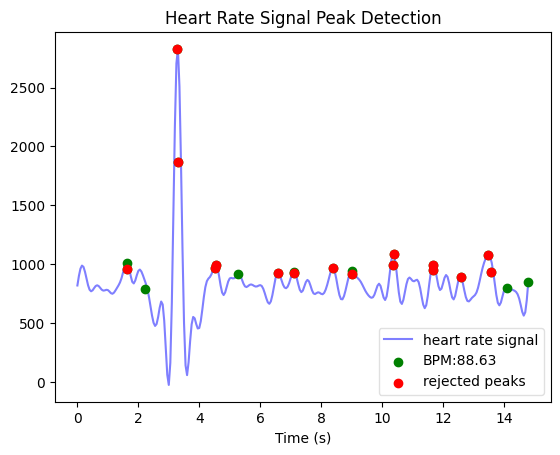

In [29]:
plt.figure(figsize=(12,6))
hp.plotter(wd, m)

for key in m.keys():
    print('%s: %f' %(key, m[key]))